This notebook tackles the [**Playground Series – Season 6, Episode 5: Predicting F1 Pit Stops**](https://www.kaggle.com/competitions/playground-series-s6e5), a competition focused on predicting the probabilty that a driver will pit on the next lap, based on with engineered features that capture tire degradation, race progression, and driver performance dynamics.

## The Approach

I plan to split the various phases of model development into a separate notebooks to streamline later work (EDA can be *time consuming*), and allow conducting multiple studies at one time.  We will follow a structured machine learning workflow across several notebooks:

1.  **Exploratory Data Analysis (EDA):** We will begin by conducting a deep dive into the dataset using `ydata_profiling` and custom visualizations. This will help us understand the data's structure, identify patterns, analyze feature distributions, check for correlations, and assess overall data quality.  **(This notebook)**
    
2.  **Data Preprocessing & Feature Engineering:** Based on insights from the EDA, we will prepare the data for modeling. This will involve strategies like encoding categorical variables and splitting combined features to extract maximum predictive value.  A `FeatureEngineering` utility class will be created so that strategies can be shared among the various model notebooks.
    
3.  **Model Development & Tuning:** Once we have evaluated the data and performed feature engineering, we will build and train a robust predictive model. In past competitions, we've started with a **LightGBM** (Light Gradient Boosting Machine) model, renowned for its high performance and efficiency. We will also leverage **Optuna** for automated hyperparameter tuning to find the best-performing model configuration.  In the last competition, I also added notebooks to train **XGBoost** and **CatBoost** models.  I will also develop a model-blending notebook to blend the predictions, which provided the best scores.
    
4.  **Submission:** Finally, we will use our tuned model to generate predictions (probabilities) on the test set and format them into a `submission.csv` file for the competition.
    
Let's begin by loading the necessary libraries and exploring the data.

## Install Needed Packages

In [1]:
%pip -q install --upgrade ydata_profiling


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import sys
import math
import random
import warnings
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# --- Third-party
import numpy as np
import pandas as pd
from IPython.display import display
from ydata_profiling import ProfileReport
import scipy.stats as st
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e05_experiment_setup import ExperimentSetup
from ps_s06e05_data_visualization import DataVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')

%matplotlib inline

In [3]:
helper = ExperimentSetup()

# Get the seed, and apply it to all the internals like pandas and numpy
seed = helper.set_seeds()

helper.configure_pandas()
helper.suppress_warnings()

# The target feature
TARGET = 'PitNextLap'

# Show GPU be utilized in training
USE_GPU = True

Random seed set to: 10301
Warnings suppressed.


## Read and Examine the Training Dataset

In [4]:
training_df = helper.read_dataset('training')

TRAINING DATASET

   id Driver Compound                   Race  Year  PitStop  LapNumber  Stint  \
0   0   D109     HARD    Canadian Grand Prix  2022        0         50      2   
1   1   D086     HARD       Dutch Grand Prix  2025        1         27      2   
2   2    ZON     HARD    Austrian Grand Prix  2022        0         59      3   
3   3    SPE   MEDIUM     Pre-Season Testing  2023        0          2      1   
4   4   D019     HARD  Azerbaijan Grand Prix  2022        1         26      3   

   TyreLife  Position  LapTime (s)  LapTime_Delta  Cumulative_Degradation  \
0    39.000         8       78.491         -7.564                  21.019   
1     7.000         4       75.095        -32.617                -223.207   
2    22.000        13       70.945         -7.540                -100.529   
3     2.000         7       94.361         -7.324                  -7.324   
4     6.000         2      107.878          8.965                 -14.139   

   RaceProgress  Position_Change

## Read and Examine the Test Dataset

In [5]:
test_df = helper.read_dataset('test')

TEST DATASET

       id Driver Compound                      Race  Year  PitStop  LapNumber  \
0  439140   D119   MEDIUM        British Grand Prix  2023        0         21   
1  439141    VER   MEDIUM      Abu Dhabi Grand Prix  2023        0         24   
2  439142   D270   MEDIUM        British Grand Prix  2023        0         24   
3  439143   D112     SOFT      São Paulo Grand Prix  2024        0          6   
4  439144    AND     HARD  United States Grand Prix  2024        0         52   

   Stint  TyreLife  Position  LapTime (s)  LapTime_Delta  \
0      1    21.000         4       93.387          0.280   
1      1    24.000         1       90.867         -0.129   
2      1    24.000        11       92.871          0.041   
3      2     4.000        15       94.967        -19.741   
4      2    29.000        12       99.112          0.930   

   Cumulative_Degradation  RaceProgress  Position_Change  
0                  -4.984         0.404            0.000  
1                  -

## Read and Examine the Original Dataset

In [6]:
original_df = helper.read_dataset('original')

ORIGINAL DATASET

  Driver  LapNumber Compound  Stint  TyreLife  Position  LapTime (s)  \
0    ALB          1   MEDIUM      1     2.000        17      100.625   
1    ALB          2   MEDIUM      1     3.000        18       93.560   
2    ALB          3   MEDIUM      1     4.000        18       91.768   
3    ALB          4   MEDIUM      1     5.000        18       91.591   
4    ALB          5   MEDIUM      1     6.000        18       91.422   

                   Race  Year  LapTime_Delta  Cumulative_Degradation  PitStop  \
0  Abu Dhabi Grand Prix  2023          0.000                   0.000        0   
1  Abu Dhabi Grand Prix  2023         -7.065                  -7.065        0   
2  Abu Dhabi Grand Prix  2023         -1.792                  -8.857        0   
3  Abu Dhabi Grand Prix  2023         -0.177                  -9.034        0   
4  Abu Dhabi Grand Prix  2023         -0.169                  -9.203        0   

   PitNextLap  RaceProgress  Normalized_TyreLife  Position_Cha

## Exploratory Data Analysis

In a previous Playground Episode, I ran across a report generator that shows histograms, tables of most common values, and various interaction plots.  Even better, it can be used to determine if the test dataset differs from the training set, and if so, how.  I spent hours poring over them, and they helped to determine which columns to concentrate on for feature engineering.  And since it creates an HTML report, it can be viewed outside the notebook, from github, for instance.

In [7]:
# Create the profile report object for the TRAINING data
training_report = ProfileReport(training_df, title='Training Data')

# Create the profile report object for the TEST data
test_report = ProfileReport(test_df, title='Test Data')

# Create the comparison report
# This compares the TEST report *against* the TRAINING report
train_test_comparison_report = training_report.compare(test_report)

# Save the combined report to an HTML file
train_test_comparison_report.to_file('training_vs_test_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:04<00:00,  3.83it/s]


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 14.98it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
# Display the HTML report in an iframe
IFrame(src='training_vs_test_comparison.html', width=1000, height=600)

We also load the original dataset to compare distributions. Note: Ensure you have added the [F1 Strategy Dataset | Pit Stop Prediction](https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/data) to your notebook input for this cell to run.

In [9]:
# Create the profile report object for the ORIGINAL data
original_report = ProfileReport(test_df, title='Original Data')

# Create the comparison report
# This compares the ORIGINAL report *against* the TRAINING report
train_original_comparison_report = training_report.compare(original_report)

# Save the combined report to an HTML file
train_original_comparison_report.to_file('training_vs_original_comparison.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 15.52it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
# Display the HTML report in an iframe
IFrame(src='training_vs_original_comparison.html', width=1000, height=600)

## Data Visualization
While the automated report provides a great overview, we will use a custom `DataVisualizer` class to dig deeper into specific relationships.

1. **Signal Ranking:** We will rank features by their Spearman correlation (for numerical features) and range of risk (for categorical features) to identify the strongest predictors.
2. **Interaction Plots:** We will generate specific plots to see how top features interact with the target.

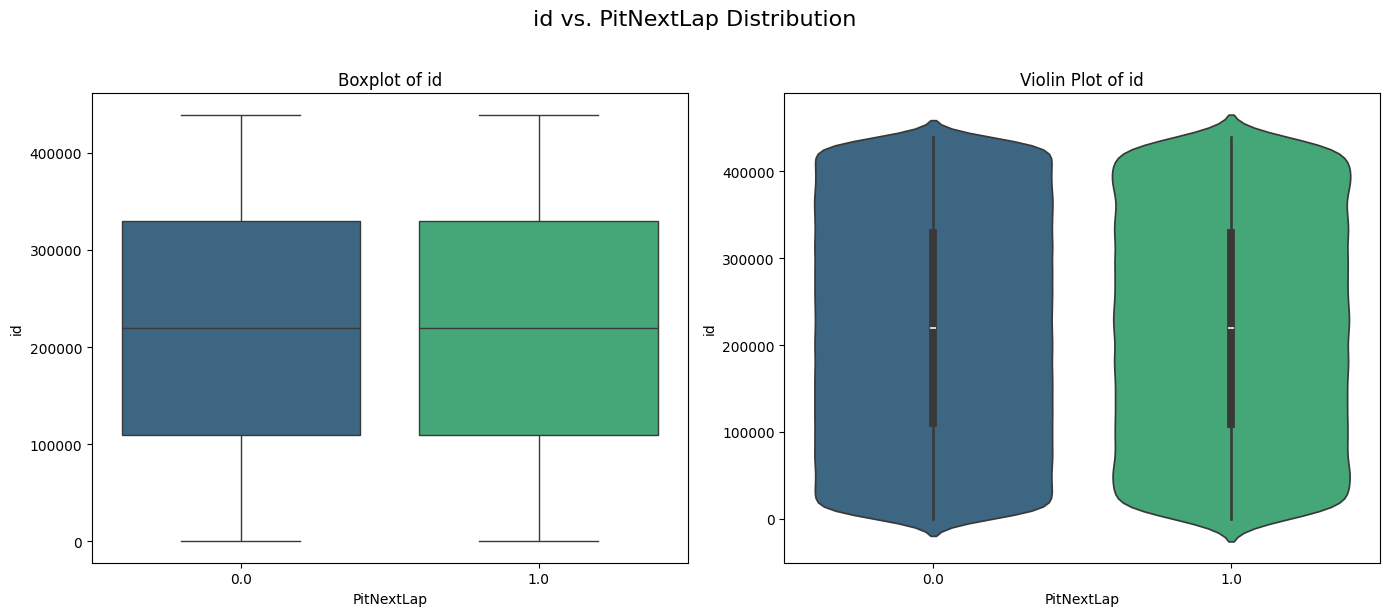

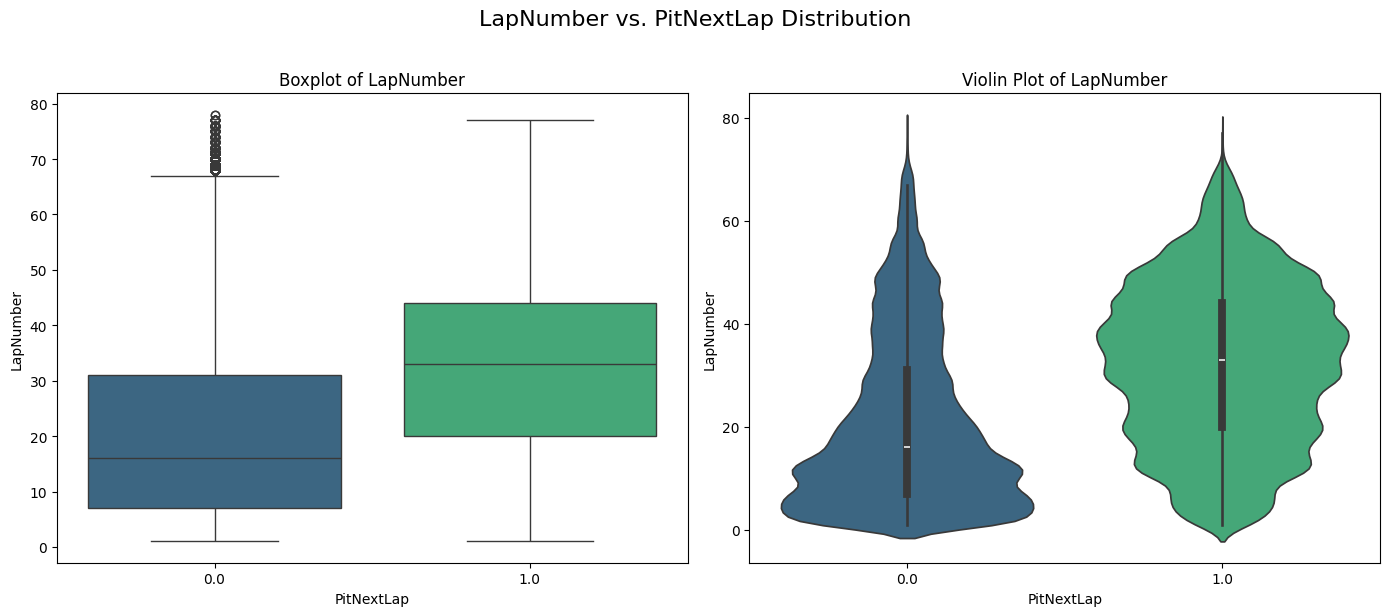

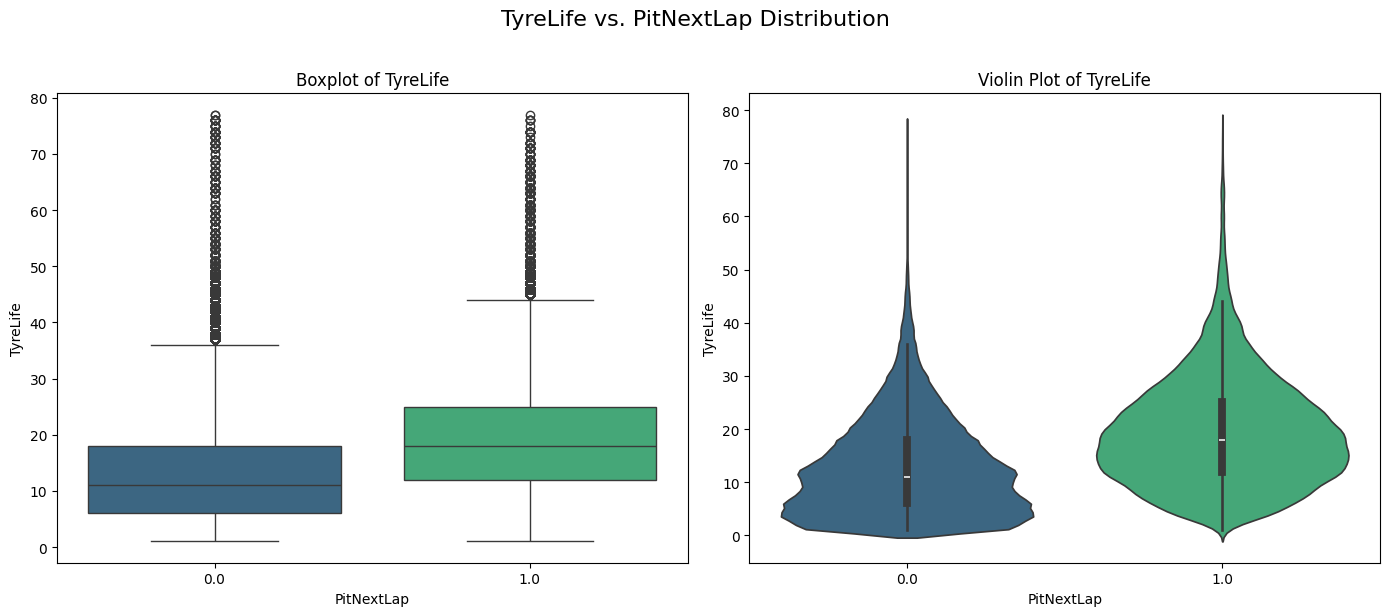

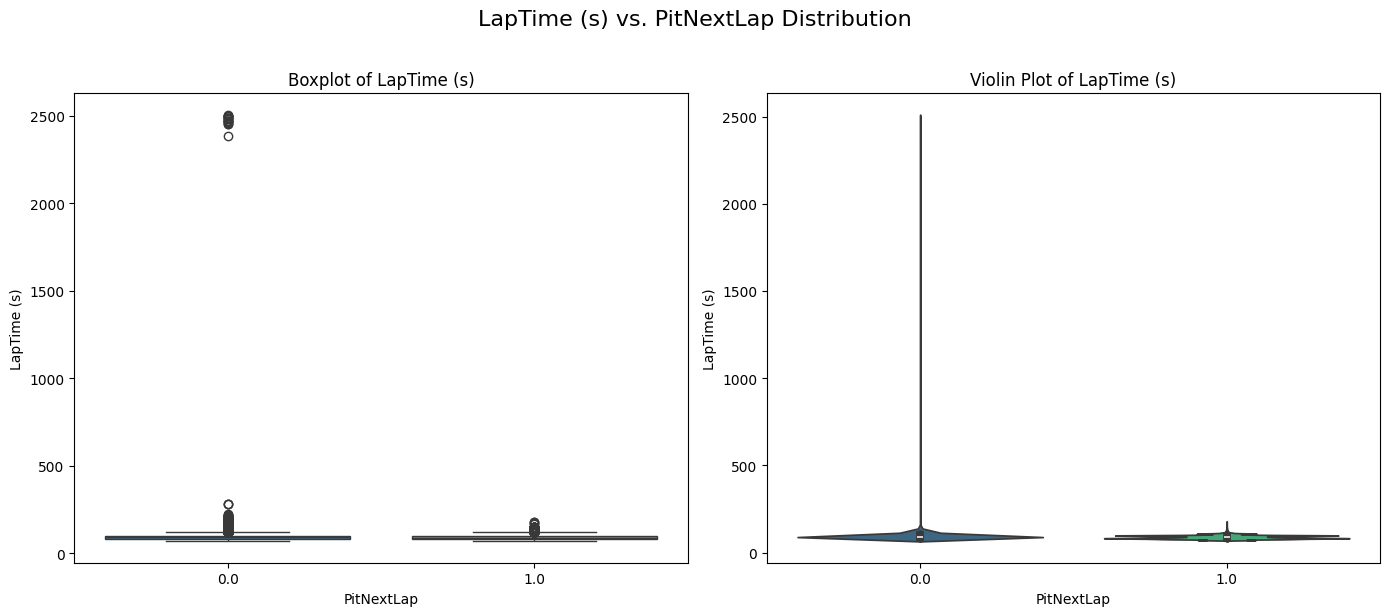

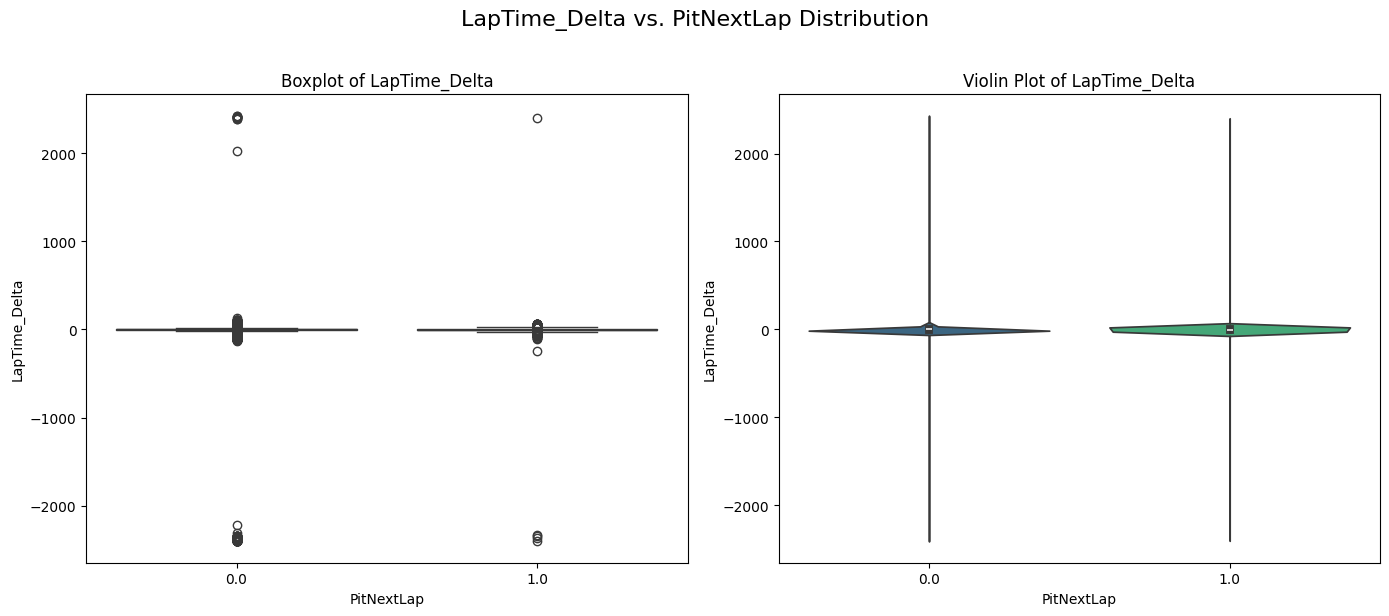

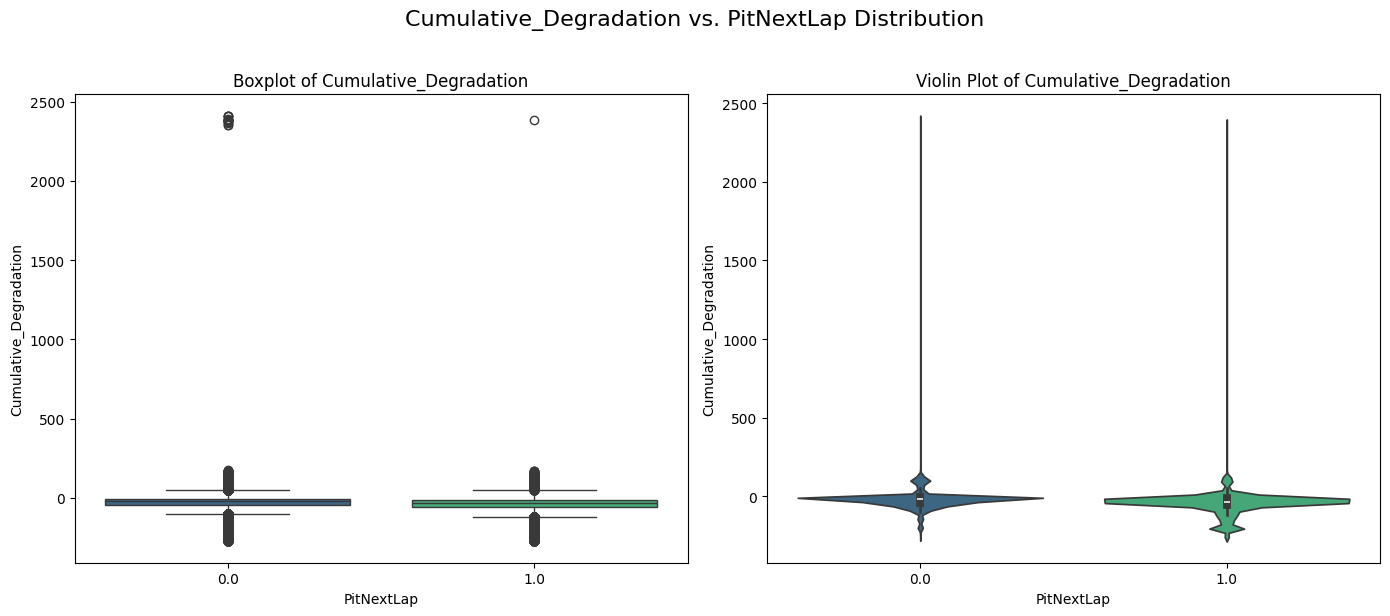

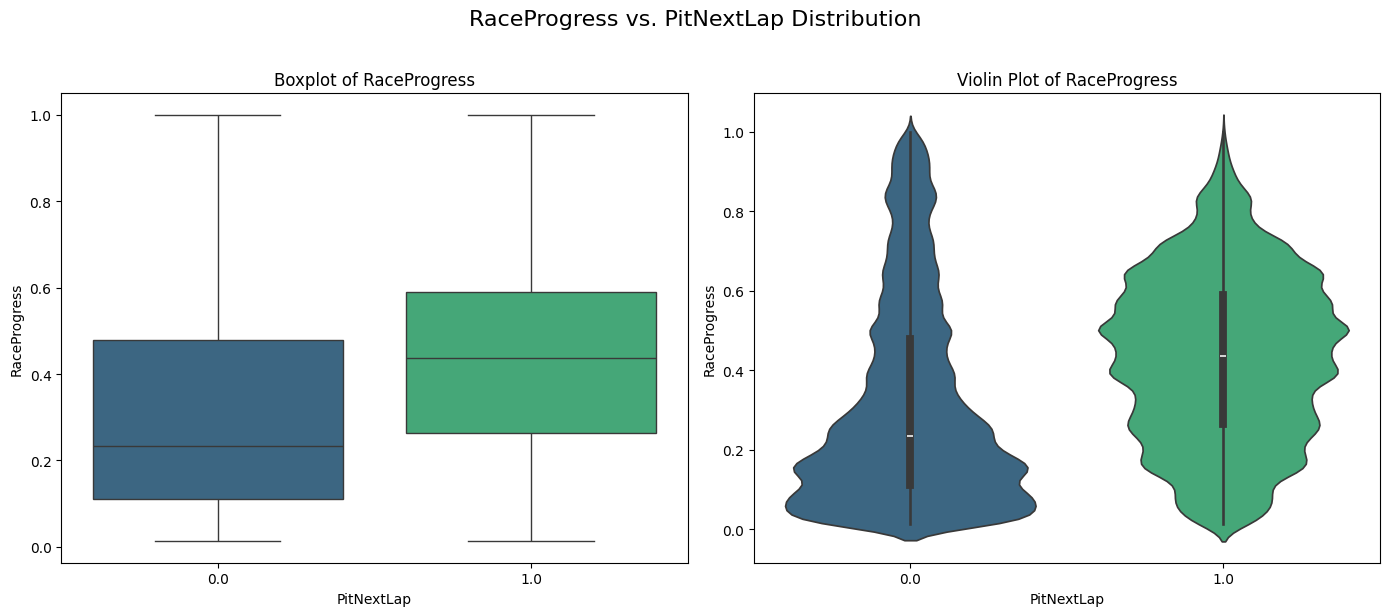

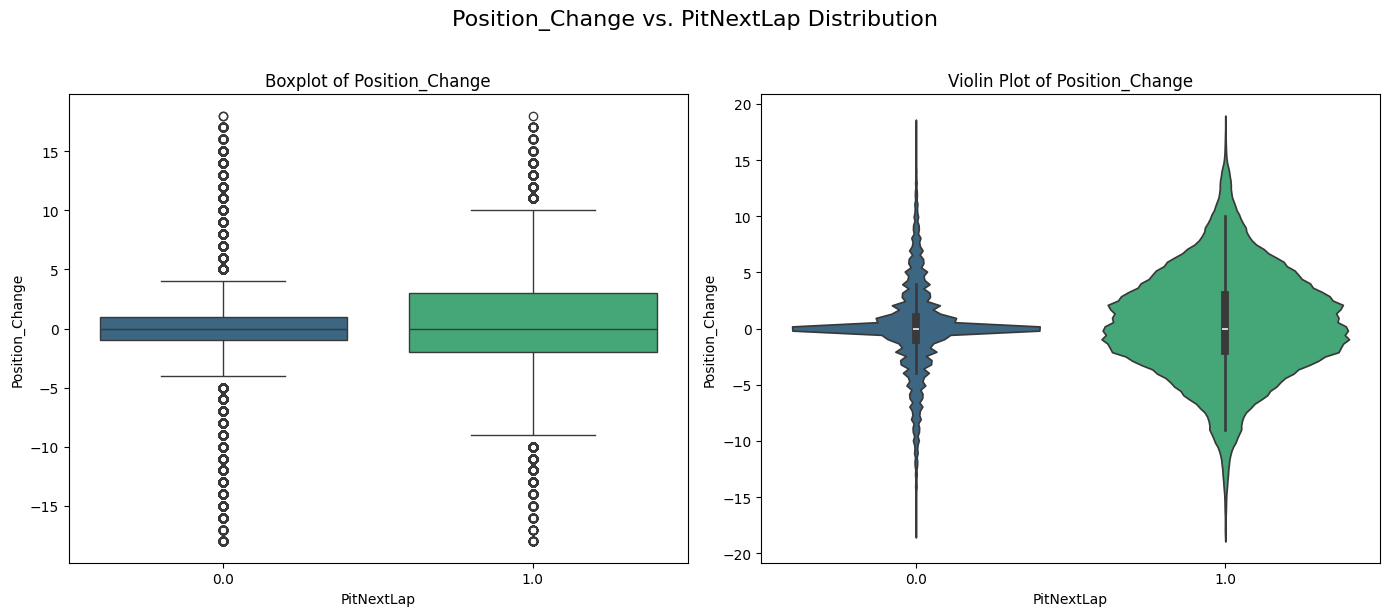

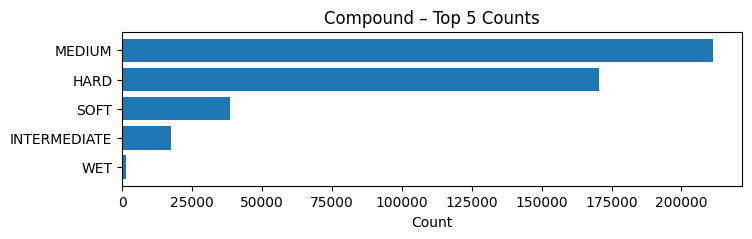

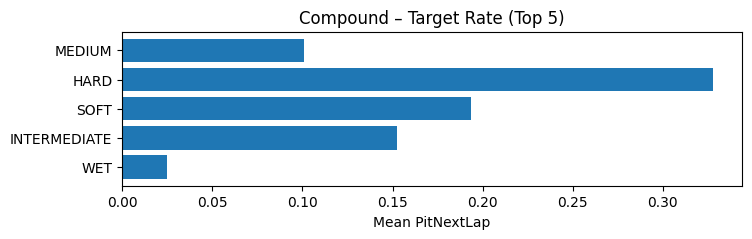

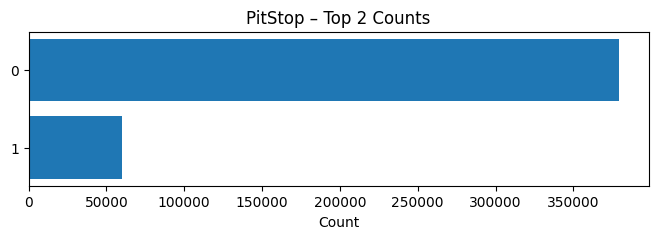

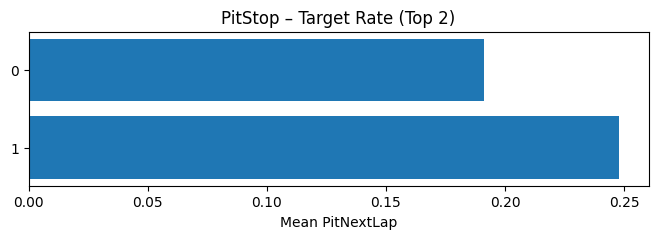

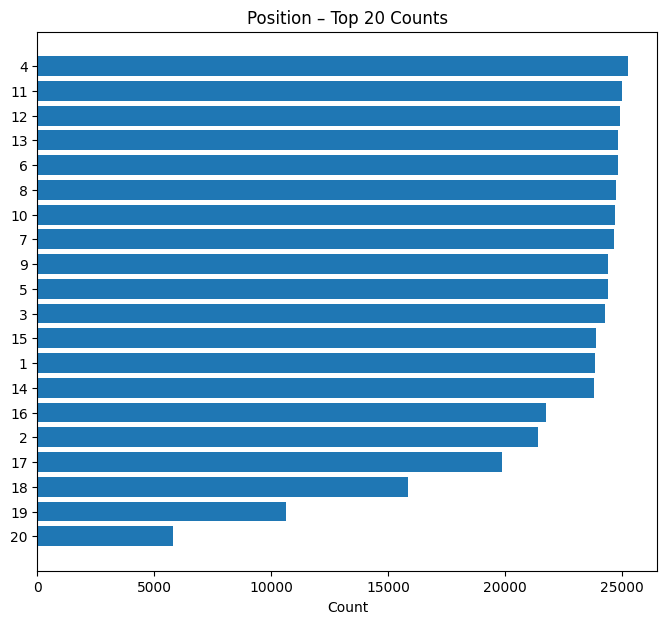

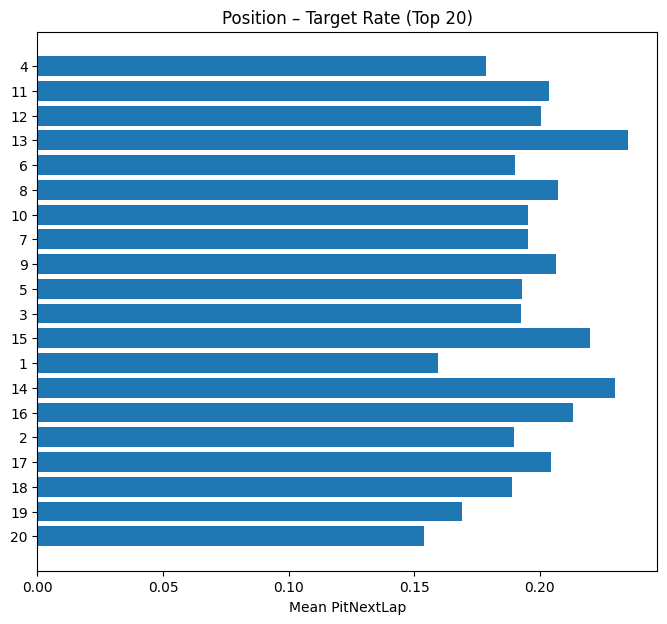

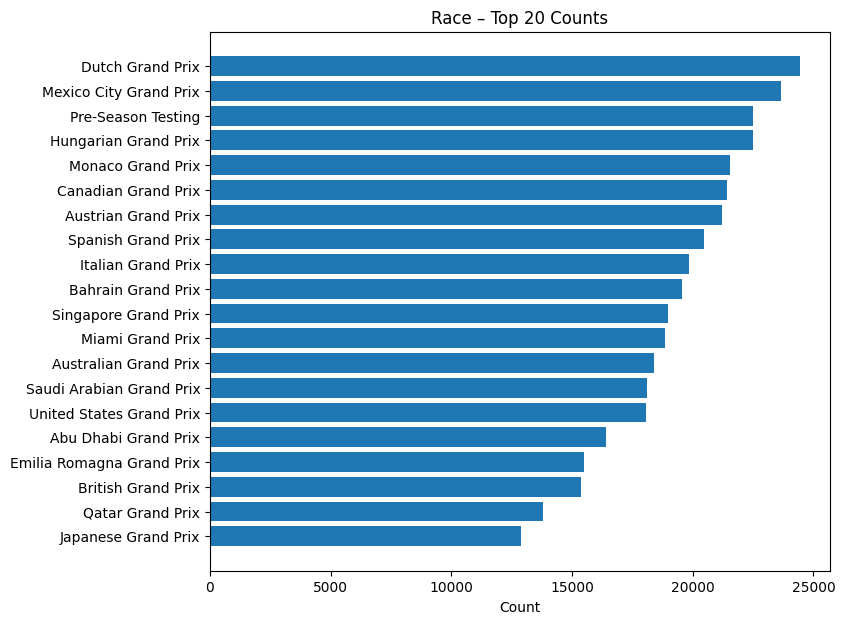

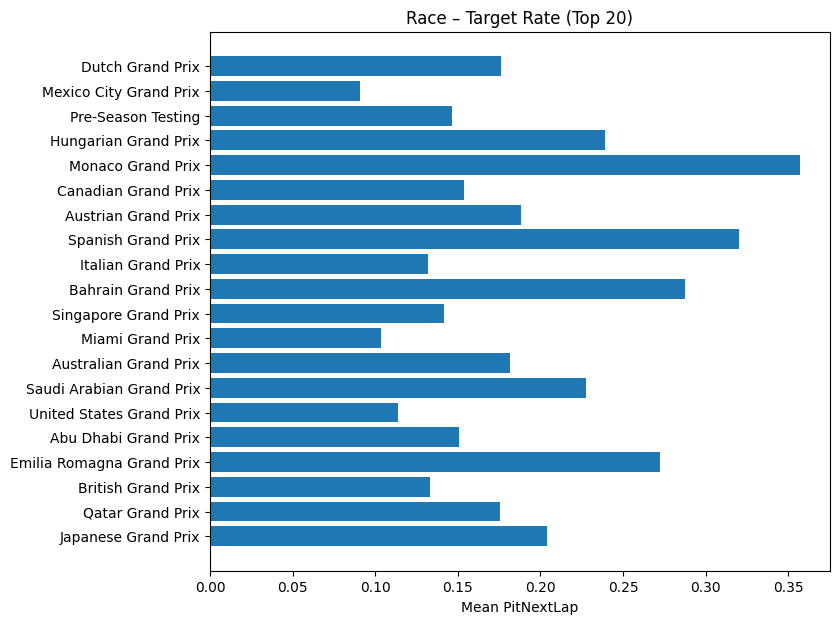

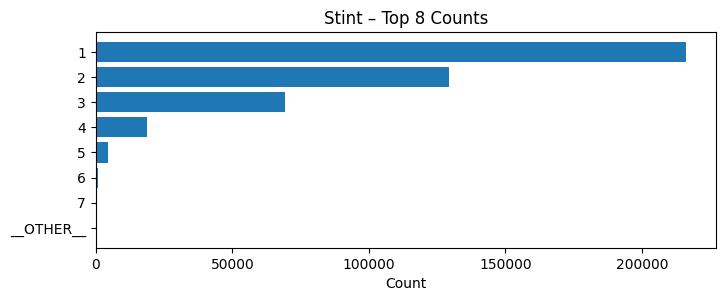

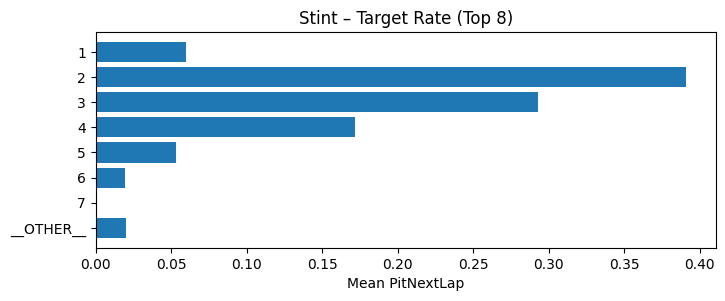

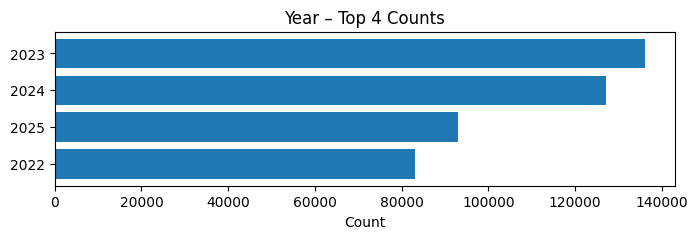

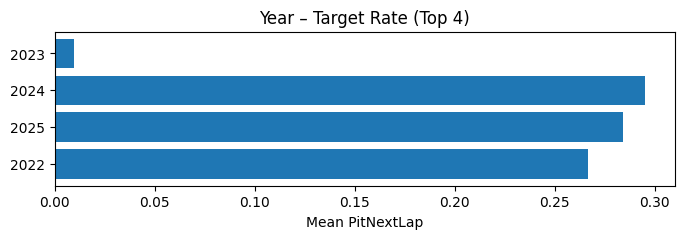

### Numeric x Category Trend

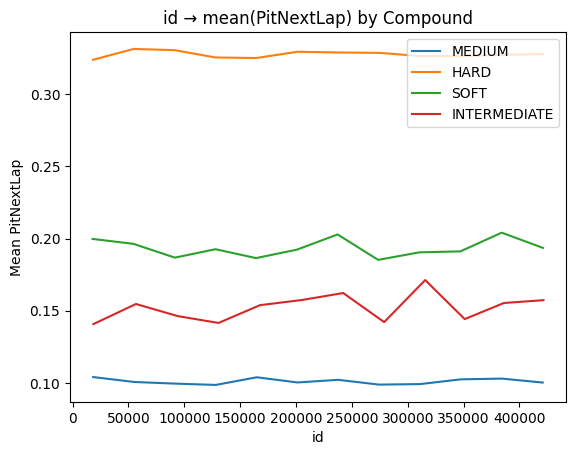

### Category x Category Trend

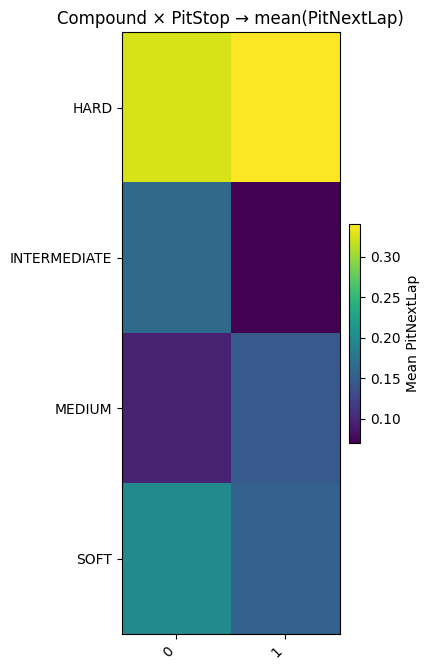

### Feature Signal Ranking

Top numeric (|Spearman|): [('LapNumber', 0.2799403526250295), ('Stint', 0.27587237768521994), ('TyreLife', 0.27531736467190465), ('RaceProgress', 0.22732404559094604), ('Cumulative_Degradation', -0.15369183728575278), ('Year', 0.13601918667566582), ('LapTime_Delta', -0.0915090475901596), ('LapTime (s)', -0.05476360141644623), ('PitStop', 0.048567219630181464), ('Position_Change', 0.0387784918284123)]
Top categorical (range of mean risk): [('Driver', 0.5654596100278552, 887), ('Compound', 0.3024450178702282, 5), ('Race', 0.2979369049004151, 26)]


In [11]:
visualizer = DataVisualizer(target=TARGET, seed=helper.get_seed())
visualizer.run_data_visualization(training_df)

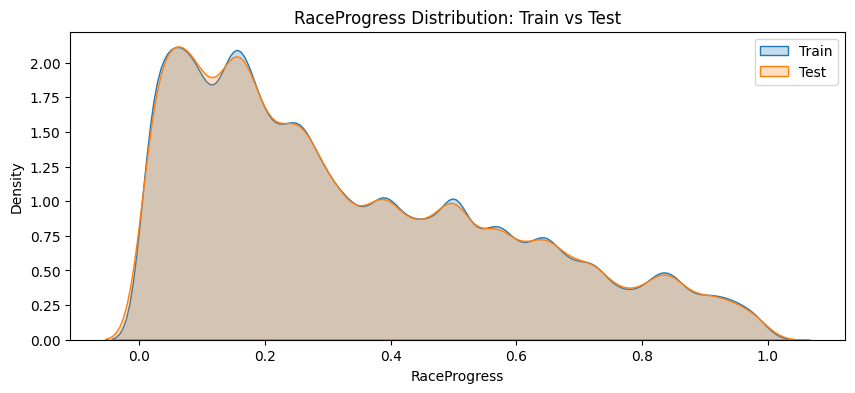

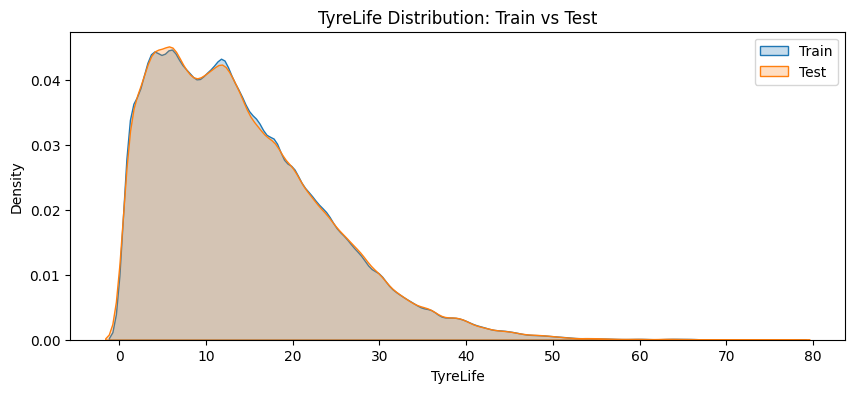

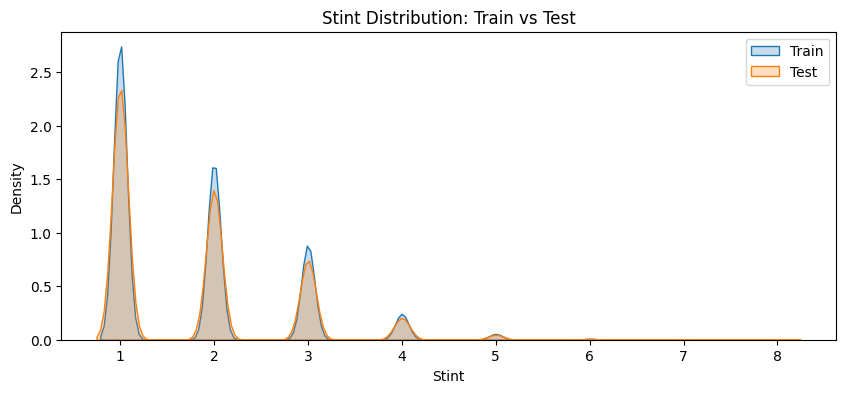

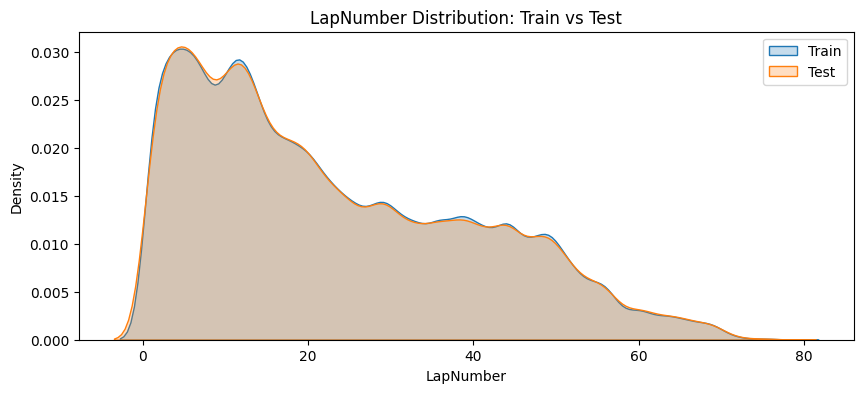

In [13]:
# Check for drift visually in top correlated features
tops=[
    'RaceProgress',
    'TyreLife',
    'Stint',
    'LapNumber'
]
for top in tops:
    plt.figure(figsize=(10, 4))
    sns.kdeplot(training_df[top], label='Train', fill=True)
    sns.kdeplot(test_df[top], label='Test', fill=True)
    plt.title(f'{top} Distribution: Train vs Test')
    plt.legend(loc='best')
    plt.show()

